# **TRABAJO PRÁCTICO - COMPUTER VISION**
## Tecnicatura Universitaria en Inteligencia Artificial
### Integrantes:
-  Sancho Almenar, Mariano S-5778/9



## Objetivo General

Desarrollar un pipeline completo de visión por computadora para la identificación de razas de perros en imágenes. El proyecto abarca desde la creación de un sistema de búsqueda por similitud hasta la implementación de un sistema de detección y clasificación en imágenes complejas, incluyendo el entrenamiento y la optimización de modelos de Deep Learning.

# Preparación de Entorno

In [1]:
!pip install -q gdown
#!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.3/31.3 MB 65.0 MB/s eta 0:00:00


In [3]:
!pip install ultralytics>=8.0.0

In [4]:
# Acordarse de agregar apt-get update && apt-get install -y libgl1 para que ande yolo

import os
import numpy as np
import zipfile
import gdown
import random
from collections import defaultdict, Counter
import faiss
import gradio as gr
from tqdm import tqdm
import tempfile
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

from pathlib import Path
import plotly.graph_objects as go
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
from ultralytics import YOLO


import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models, datasets, transforms
from torch.utils.data import DataLoader

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [14]:
os.makedirs('outputs/plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Descarga y Preparación del Dataset

## Descarga y unzip

In [6]:
!gdown --fuzzy "https://drive.google.com/file/d/1dvh89pjjxdmG0JkWuFhZkE12w-_g0wOm/view?usp=sharing" -O dataset.zip

with zipfile.ZipFile("dataset.zip", "r") as zip_ref:
    zip_ref.extractall("data/")

Downloading...
From (original): https://drive.google.com/uc?id=1dvh89pjjxdmG0JkWuFhZkE12w-_g0wOm
From (redirected): https://drive.google.com/uc?id=1dvh89pjjxdmG0JkWuFhZkE12w-_g0wOm&confirm=t&uuid=17f08241-7385-46f1-8cee-1e3c6ad6dbc4
To: /content/dataset.zip
100% 225M/225M [00:01<00:00, 130MB/s]


## Preparación del Dataset

In [ ]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)

# Para entrenamiento (con data augmentation)
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Para validación y test (sin aumentos)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Cargar datasets
trainset = datasets.ImageFolder(root='./data/train', transform=train_transform)
validset = datasets.ImageFolder(root='./data/valid', transform=test_transform)
testset  = datasets.ImageFolder(root='./data/test',  transform=test_transform)

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
validloader = DataLoader(validset, batch_size=BATCH_SIZE, shuffle=False)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## EDA

### Cantidad de Clases

In [9]:
class_names = trainset.classes
num_classes = len(class_names)
print(f"El dataset cuenta con un total de {num_classes} clases")
print(class_names)


El dataset cuenta con un total de 70 clases
['Afghan', 'African Wild Dog', 'Airedale', 'American Hairless', 'American Spaniel', 'Basenji', 'Basset', 'Beagle', 'Bearded Collie', 'Bermaise', 'Bichon Frise', 'Blenheim', 'Bloodhound', 'Bluetick', 'Border Collie', 'Borzoi', 'Boston Terrier', 'Boxer', 'Bull Mastiff', 'Bull Terrier', 'Bulldog', 'Cairn', 'Chihuahua', 'Chinese Crested', 'Chow', 'Clumber', 'Cockapoo', 'Cocker', 'Collie', 'Corgi', 'Coyote', 'Dalmation', 'Dhole', 'Dingo', 'Doberman', 'Elk Hound', 'French Bulldog', 'German Sheperd', 'Golden Retriever', 'Great Dane', 'Great Perenees', 'Greyhound', 'Groenendael', 'Irish Spaniel', 'Irish Wolfhound', 'Japanese Spaniel', 'Komondor', 'Labradoodle', 'Labrador', 'Lhasa', 'Malinois', 'Maltese', 'Mex Hairless', 'Newfoundland', 'Pekinese', 'Pit Bull', 'Pomeranian', 'Poodle', 'Pug', 'Rhodesian', 'Rottweiler', 'Saint Bernard', 'Schnauzer', 'Scotch Terrier', 'Shar_Pei', 'Shiba Inu', 'Shih-Tzu', 'Siberian Husky', 'Vizsla', 'Yorkie']


### Distribución de imágenes por clase

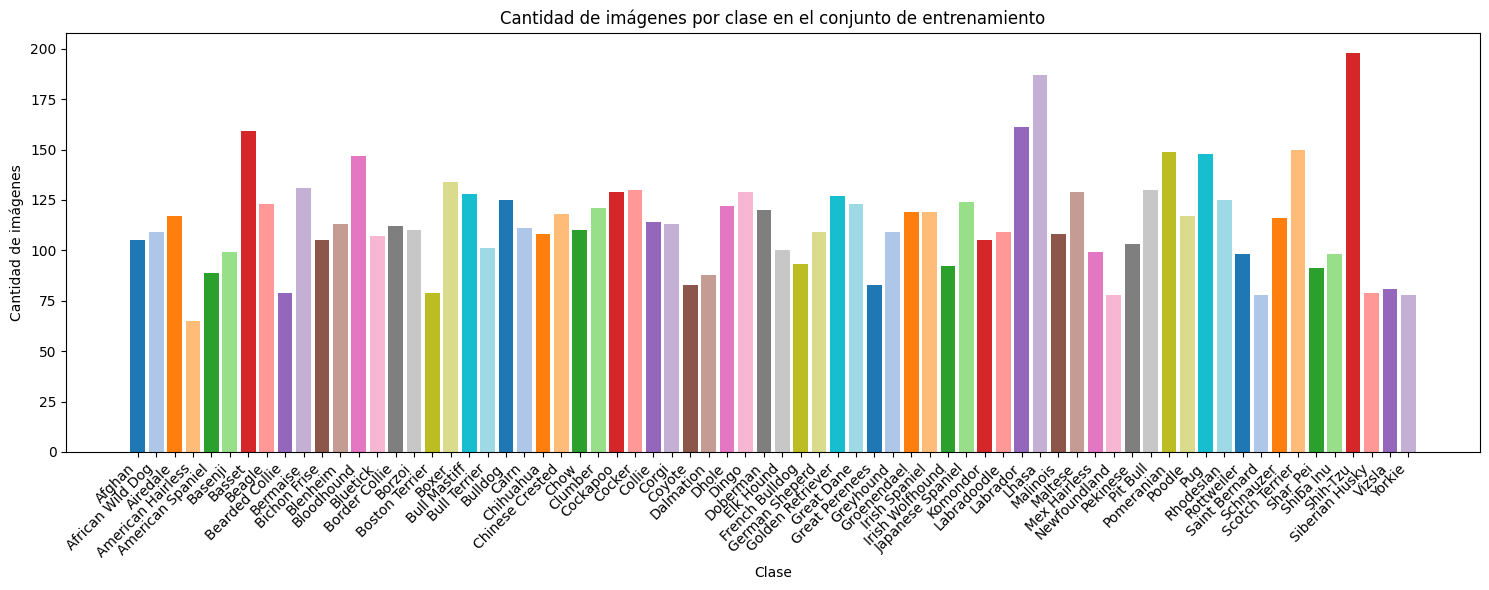

In [15]:
# Contar cuántas imágenes hay por clase
class_counts = Counter(trainset.targets)

counts_array = np.array([class_counts[i] for i in range(len(class_names))])

# Gráfico
plt.figure(figsize=(15, 6))
bars = plt.bar(class_names, counts_array, color=plt.cm.tab20.colors[:len(class_names)])

plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.title('Cantidad de imágenes por clase en el conjunto de entrenamiento')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('outputs/plots/class_distribution.png')
plt.show()

Se observa que no hay un gran balanceo entre clases. Siendo 'Shih-Tzu' la clase con mayor cantidad de imágenes (198) y 'American Hairless' con 68

### Visualización de algunas imágenes

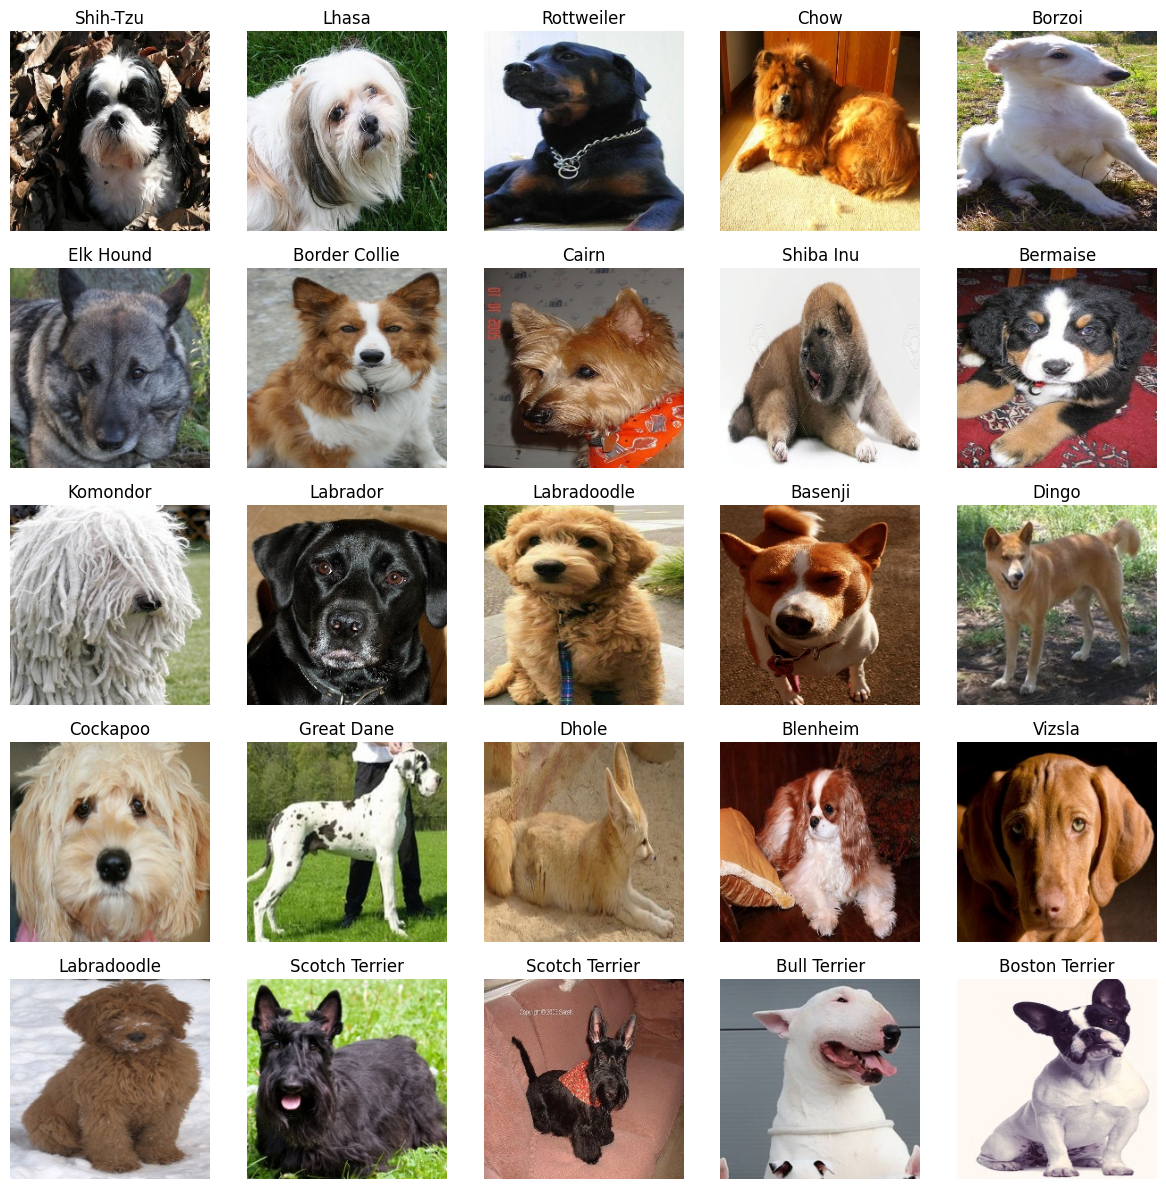

In [16]:
plt.figure(figsize=(12, 12))

# Obtener una sola tanda (batch) del DataLoader
images, labels = next(iter(trainloader))


for i in range(25):
    ax = plt.subplot(5, 5, i + 1)

    # Desnormalizar imagen (ImageNet)
    img = images[i].numpy().transpose((1, 2, 0))  # CHW -> HWC
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.title(trainset.classes[labels[i]])
    plt.axis("off")

plt.tight_layout()
plt.savefig('outputs/plots/images_examples.png')
plt.show()

# **Etapa 1**:  Buscador de Imágenes por Similitud

## Creación de la Base de Datos Vectorial


In [17]:
def prepare_faiss_index(dataloader, model, device, class_names):
    all_features = []
    image_paths = []
    image_labels = []

    temp_dir = tempfile.mkdtemp()
    model.eval()

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader):
            images = images.to(device)

            features = model(images).squeeze(-1).squeeze(-1).cpu().numpy()
            all_features.append(features)

            for img_idx, (img_tensor, label) in enumerate(zip(images.cpu(), labels)):
                # Desnormalizar la imagen para guardarla
                img_array = img_tensor.numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_array = std * img_array + mean  # Desnormalizar
                img_array = (img_array * 255).clip(0, 255).astype("uint8")

                # Convertir a imagen RGB
                if img_array.shape[2] == 1:
                    img_array = np.repeat(img_array, 3, axis=2)

                img_pil = Image.fromarray(img_array)
                path = os.path.join(temp_dir, f"resnet_b{batch_idx}_i{img_idx}.jpg")
                img_pil.save(path)

                image_paths.append(path)
                image_labels.append(class_names[label.item()])

    all_features = np.concatenate(all_features, axis=0).astype("float32")
    index = faiss.IndexFlatL2(all_features.shape[1])
    index.add(all_features)

    return index, image_paths, image_labels


In [10]:
# Importo Modelo ResNet50 pre-entrenado
rn50_model =  models.resnet50(pretrained=True)

# Eliminar la última capa fully-connected (la de clasificación)
rn50_model = torch.nn.Sequential(*(list(rn50_model.children())[:-1]))

# Congelar todos los parámetros
for param in rn50_model.parameters():
    param.requires_grad_(False)

rn50_model = rn50_model.to(device)
rn50_model.eval();

# Creación Base Vectorial
index, image_paths, image_labels = prepare_faiss_index(trainloader, rn50_model, device, class_names)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 71.2MB/s]
Procesando ResNet50: 100%|██████████| 249/249 [01:06<00:00,  3.74it/s]


## Clasificación Basada en Similitud y Métrica de Evaluación

### Búsqueda de imágenes similares


In [18]:
def find_similar_images(img_input, model, index, image_paths, image_labels, device, k=10):

    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img = transform(img_input)

    # Mover a dispositivo y añadir dimensión de batch si es necesario
    img = img.to(device)
    if img.dim() == 3:
        img = img.unsqueeze(0)

    model.eval()

    with torch.no_grad():
        features = model(img).squeeze(-1).squeeze(-1).cpu().numpy().astype("float32")

    distances, indices = index.search(features, k)

    similar_images = [(image_paths[i], image_labels[i], float(distances[0][j]))
                    for j, i in enumerate(indices[0])]

    breeds = [label for _, label, _ in similar_images]
    predicted_breed = Counter(breeds).most_common(1)[0][0]

    return similar_images, predicted_breed

### NDCG

In [19]:
def select_test_subset(dataset, class_names, k=5):
    """
    Selecciona aleatoriamente k imágenes por clase del dataset
    Args:
        dataset: PyTorch Dataset (como testset)
        class_names: Lista de nombres de clases
        k: Número de imágenes por clase a seleccionar
    """
    class_to_images = defaultdict(list)

    # Iterar sobre el dataset completo
    for idx in range(len(dataset)):
        img_tensor, class_idx = dataset[idx]
        class_name = class_names[class_idx]
        class_to_images[class_name].append((img_tensor, class_name))

    # Seleccionar k imágenes por clase
    test_subset = []
    for class_name, samples in class_to_images.items():
        selected = random.sample(samples, k=min(len(samples), k))
        test_subset.extend(selected)

    print(f"Total de imágenes seleccionadas: {len(test_subset)}")
    return test_subset

def tensor_to_pil(img_tensor):
    """Convierte tensor PyTorch a PIL Image"""
    # 1. Convertir tensor a numpy y reordenar dimensiones
    img_array = img_tensor.numpy().transpose((1, 2, 0))

    # 2. Desnormalizar (usando los parámetros de ImageNet)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_array = std * img_array + mean

    # 3. Escalar a [0, 255] y convertir a uint8
    img_array = (img_array * 255).clip(0, 255).astype("uint8")

    # 4. Convertir a PIL Image
    return Image.fromarray(img_array)

def ndcg_at_k(true_label, pred_labels, k=10):
    """Calcula NDCG@k para una consulta"""
    relevances = [1 if label == true_label else 0 for label in pred_labels[:k]]
    dcg = sum([rel / np.log2(i + 2) for i, rel in enumerate(relevances)])
    idcg = sum([1 / np.log2(i + 2) for i in range(min(k, sum(relevances)))])
    return dcg / idcg if idcg > 0 else 0

In [ ]:
test_subset = select_test_subset(testset, class_names, k=6)

# 3. Calcular NDCG para cada imagen
ndcg_scores = []

for img_tensor, true_label in test_subset:
    # Convertir tensor a PIL Image
    img_pil = tensor_to_pil(img_tensor)

    # Buscar imágenes similares
    similar_images, _ = find_similar_images(
        img_pil, rn50_model, index, image_paths, image_labels, device, k=10
    )

    # Obtener etiquetas de los resultados
    retrieved_labels = [label for _, label, _ in similar_images]

    # Calcular NDCG
    score = ndcg_at_k(true_label, retrieved_labels, k=10)
    ndcg_scores.append(score)

# 4. Calcular métricas finales
average_ndcg = np.mean(ndcg_scores)
std_ndcg = np.std(ndcg_scores)

print("\n" + "="*50)
print(f"NDCG@10 promedio: {average_ndcg:.4f} ± {std_ndcg:.4f}")

## Interfaz de Gradio

In [ ]:
from functools import partial
def gradio_interface(img_input, average_ndcg):
    similar_images, predicted_breed = find_similar_images(
        img_input, rn50_model, index, image_paths, image_labels, device, k=10
    )

    # Usa PIL para que Gradio los muestre correctamente
    output_imgs = [Image.open(img_path) for img_path, _, _ in similar_images]

    ndcg_text = round(average_ndcg, 2)
    return output_imgs, predicted_breed, ndcg_text

iface = gr.Interface(
    fn=partial(gradio_interface, average_ndcg=average_ndcg),
    inputs=gr.Image(type="pil", label="Sube una imagen de perro"),
    outputs=[
        gr.Gallery(label="Imágenes más similares", columns=5),
        gr.Textbox(label="Predicción de raza por mayoría"),
        gr.Textbox(label="NDCG@10 promedio sobre subconjunto de prueba")
    ],
    title="Buscador de similitud y clasificación de razas de perros",
    description="Sube una imagen de perro para encontrar imágenes similares y predecir su raza."
)

iface.launch()

# **Etapa 2**: Entrenamiento y Comparación de modelos de Clasificación

## Definición de funciones y clases

In [22]:
# Se crea la Clase History para almacenar los historiales de entrenamiento en los modelos de Resnet18 para luego graficarlos
class History:
    def __init__(self):
        self.history = {
            'accuracy': [],
            'val_accuracy': [],
            'loss': [],
            'val_loss': []
        }

In [23]:
def acc_loss_plot(model_history: History) -> None:
    """
    Función para graficar accuracy y loss para train y validación.

    Args:
        model_history: Historia de entrenamiento del modelo.
    """
    os.makedirs("outputs", exist_ok=True)

    plt.figure(figsize=(10, 8))

    # Accuracy
    plt.subplot(2, 2, 1)
    plt.title("Accuracy Train/Validación con respecto a las épocas")
    plt.plot(model_history.history['accuracy'], label='Train Accuracy')
    plt.plot(model_history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim([0, 1])
    plt.legend(loc='lower right')

    # Loss
    plt.subplot(2, 2, 2)
    plt.title("Loss Train/Validación con respecto a las épocas")
    plt.plot(model_history.history['loss'], label='Train Loss')
    plt.plot(model_history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.ylim([0, 3])
    plt.legend(loc='upper right')

    plt.tight_layout()
    plt.savefig(f"outputs/plots/{model_history}_acc_loss_plot.png")
    plt.show()

In [56]:
def train_model(model, trainloader, validloader, criterion, optimizer, scheduler, num_epochs=10, device='cpu', save_path='model.pth'):
    """
    Entrena un modelo y guarda el mejor según validación.

    Args:
        model: modelo a entrenar (ya configurado)
        trainloader: DataLoader de entrenamiento
        validloader: DataLoader de validación
        criterion: función de pérdida
        optimizer: optimizador
        scheduler: scheduler de LR
        num_epochs: número de épocas a entrenar
        device: 'cuda' o 'cpu'
        save_path: ruta para guardar el mejor modelo

    Returns:
        history: objeto History con métricas de entrenamiento/validación
    """
    best_acc = 0.0
    history = History()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

        train_acc = correct / total
        train_loss = running_loss / len(trainloader)

        # Validación
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in validloader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                _, preds = torch.max(outputs, 1)

                val_loss += loss.item()
                val_total += labels.size(0)
                val_correct += (preds == labels).sum().item()

        val_acc = val_correct / val_total
        val_loss /= len(validloader)

        # Guardar historial
        history.history['accuracy'].append(train_acc)
        history.history['val_accuracy'].append(val_acc)
        history.history['loss'].append(train_loss)
        history.history['val_loss'].append(val_loss)

        # Guardar mejor modelo
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), save_path)
            print("✅ Mejor modelo guardado")

        scheduler.step()

        print(f"Epoch [{epoch+1}/{num_epochs}] - "
              f"Loss: {train_loss:.4f} - Acc: {train_acc:.4f} - "
              f"Val_Loss: {val_loss:.4f} - Val_Acc: {val_acc:.4f}")

    print("Entrenamiento finalizado")

    return model, history

In [25]:
def get_predictions(model, dataloader, device):
    """
    Obtiene predicciones del modelo para un dataloader dado.

    Args:
        model (nn.Module): Modelo de PyTorch ya entrenado
        dataloader (DataLoader): DataLoader con los datos a evaluar
        device (torch.device): Dispositivo donde se ejecutará el modelo ('cpu' o 'cuda')

    Returns:
        tuple: (imagenes, etiquetas_reales, etiquetas_predichas, probabilidades)
    """
    model.eval()  # Aseguramos que el modelo esté en modo evaluación
    all_images = []
    true_labels = []
    pred_labels = []


    with torch.no_grad():  # Desactivamos el cálculo de gradientes
        for images, labels in dataloader:
            # Mover datos al dispositivo (GPU/CPU)
            images = images.to(device)
            labels = labels.to(device)

            # Obtener predicciones
            outputs = model(images)

            # Calcular probabilidades y clases predichas
            _, predicted = torch.max(outputs, 1)

            # Guardar resultados
            all_images.append(images.cpu())
            true_labels.append(labels.cpu())
            pred_labels.append(predicted.cpu())


    # Concatenar todos los batches
    all_images = torch.cat(all_images, dim=0)
    true_labels = torch.cat(true_labels, dim=0)
    pred_labels = torch.cat(pred_labels, dim=0)


    return all_images, true_labels, pred_labels

In [19]:
# def get_preds_labels_tf(model, dataset):
#     """
#     Obtiene las predicciones y etiquetas verdaderas de un dataset de TensorFlow,
#     y las convierte a nombres de clases.

#     Args:
#         model: modelo TensorFlow/Keras
#         dataset: tf.data.Dataset con atributo class_names

#     Returns:
#         y_true: lista de etiquetas verdaderas (nombres)
#         y_pred: lista de etiquetas predichas (nombres)
#     """
#     y_true = []
#     y_pred = []
#     class_names = dataset.class_names

#     for images, labels in dataset:
#         preds = model.predict(images)
#         preds_classes = np.argmax(preds, axis=1)
#         true_classes = np.argmax(labels.numpy(), axis=1)

#         y_pred.extend(preds_classes)
#         y_true.extend(true_classes)

#     # Convertir índices a nombres
#     y_true_names = [class_names[i] for i in y_true]
#     y_pred_names = [class_names[i] for i in y_pred]

#     return y_true_names, y_pred_names

In [26]:
def plot_confusion_matrix(y_true, y_pred, classes=None, title='Matriz de Confusión'):
    """
    Genera y muestra una matriz de confusión usando Plotly, sin normalización.

    Args:
        y_true: lista o array de etiquetas reales
        y_pred: lista o array de etiquetas predichas
        classes: lista de nombres de clases (opcional)
        title: título del gráfico
    """
    cm = confusion_matrix(y_true, y_pred)

    if classes is None:
        classes = [str(i) for i in range(len(cm))]

    fig = go.Figure(data=go.Heatmap(
        z=cm,
        x=classes,
        y=classes,
        colorscale='Blues',
        hoverongaps=False,
        text=cm,
        texttemplate="%{text}",
        colorbar=dict(title='Frecuencia')
    ))

    fig.update_layout(
        title=title,
        xaxis_title='Predicción',
        yaxis_title='Etiqueta Real',
        yaxis=dict(autorange='reversed'),
        width=1200,
        height=1200
    )

    fig.show()

In [27]:
def compute_metrics(y_true, y_pred, labels=None, average='macro'):
    """
    Calcula métricas de evaluación para clasificación multiclase.

    Args:
        y_true: Lista de etiquetas reales (str o int)
        y_pred: Lista de etiquetas predichas
        labels: Lista de clases en orden (opcional, útil para especificidad)
        average: 'macro', 'micro', 'weighted' o 'none' (para recall, precision y F1)

    Returns:
        Diccionario con métricas
    """
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    # Especificidad: TN / (TN + FP), se calcula por clase
    specificity_per_class = []
    for i in range(len(cm)):
        tp = cm[i, i]
        fn = cm[i, :].sum() - tp
        fp = cm[:, i].sum() - tp
        tn = cm.sum() - (tp + fn + fp)
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        specificity_per_class.append(specificity)

    return {
        "Exactitud (Accuracy)": accuracy_score(y_true, y_pred),
        "Precisión (Precision)": precision_score(y_true, y_pred, average=average, zero_division=0),
        "Sensibilidad (Recall)": recall_score(y_true, y_pred, average=average, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average=average, zero_division=0),
        "Especificidad (avg)": np.mean(specificity_per_class)
    }


## Entrenamiento de Modelos

### Transfer Learning

Se importa el modelo ResNet18 preentrenado y luego se le realizará un fine-tunning.

Se evaluará el desempeño tanto del modelo base como el modificado.

#### Modelo Base

Entrena sólo la capa final

In [28]:
rn18_model = models.resnet18(pretrained=True)

# Modificar la última capa para el número de clases
rn18_model.fc = nn.Linear(rn18_model.fc.in_features, len(class_names))

# Congelar todos los parámetros
for param in rn18_model.parameters():
    param.requires_grad = False

# Descongelar parámetros de la última capa
for param in rn18_model.fc.parameters():
    param.requires_grad = True


rn18_model = rn18_model.to(device)


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, rn18_model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 174MB/s]


In [29]:
# Entrenamiento
base_model, base_history = train_model(rn18_model,
                           trainloader,
                           validloader,
                           criterion,
                           optimizer,
                           scheduler,
                           num_epochs=10,
                           device=device,
                           save_path='models/base_model.pth')

✅ Mejor modelo guardado
Epoch [1/5] - Loss: 1.6731 - Acc: 0.6501 - Val_Loss: 0.7222 - Val_Acc: 0.8800
✅ Mejor modelo guardado
Epoch [2/5] - Loss: 0.5890 - Acc: 0.8593 - Val_Loss: 0.5826 - Val_Acc: 0.8986
✅ Mejor modelo guardado
Epoch [3/5] - Loss: 0.4393 - Acc: 0.8855 - Val_Loss: 0.5689 - Val_Acc: 0.9057
✅ Mejor modelo guardado
Epoch [4/5] - Loss: 0.3682 - Acc: 0.9010 - Val_Loss: 0.5608 - Val_Acc: 0.9086
✅ Mejor modelo guardado
Epoch [5/5] - Loss: 0.3207 - Acc: 0.9130 - Val_Loss: 0.5615 - Val_Acc: 0.9129
Entrenamiento finalizado


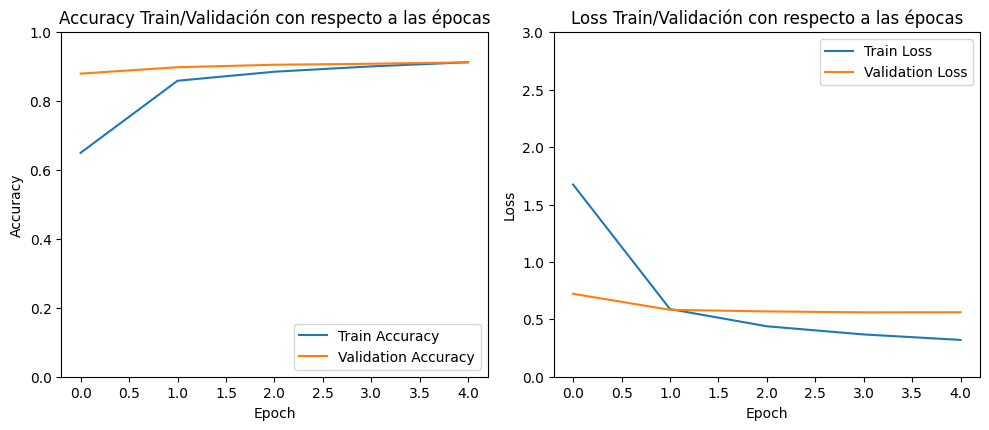

In [30]:
acc_loss_plot(base_history)

### Fine-Tuning ResNet18

In [31]:
# Modelo fine-tuned (todas las capas entrenables)
ft_model = models.resnet18(pretrained=True)
ft_model.fc = nn.Linear(ft_model.fc.in_features, len(class_names))

for param in ft_model.parameters():
    param.requires_grad = True
ft_model = ft_model.to(device)

ft_optimizer = optim.Adam(ft_model.parameters(), lr=1e-4)
ft_scheduler = optim.lr_scheduler.StepLR(ft_optimizer, step_size=5, gamma=0.5)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [67]:
# Entrenamiento del modelo fine-tuned
ft_model, ft_history = train_model(ft_model,
                         trainloader,
                         validloader,
                         criterion,
                         ft_optimizer,
                         ft_scheduler,
                         num_epochs=5,
                         device=device,
                         save_path='models/ft_rn18_model.pth')

✅ Mejor modelo guardado
Epoch [1/5] - Loss: 0.2583 - Acc: 0.9515 - Val_Loss: 0.4319 - Val_Acc: 0.9257
✅ Mejor modelo guardado
Epoch [2/5] - Loss: 0.1450 - Acc: 0.9760 - Val_Loss: 0.4205 - Val_Acc: 0.9414
Epoch [3/5] - Loss: 0.0933 - Acc: 0.9850 - Val_Loss: 0.3982 - Val_Acc: 0.9371
Epoch [4/5] - Loss: 0.0565 - Acc: 0.9916 - Val_Loss: 0.4076 - Val_Acc: 0.9329
Epoch [5/5] - Loss: 0.0324 - Acc: 0.9962 - Val_Loss: 0.4163 - Val_Acc: 0.9371
Entrenamiento finalizado


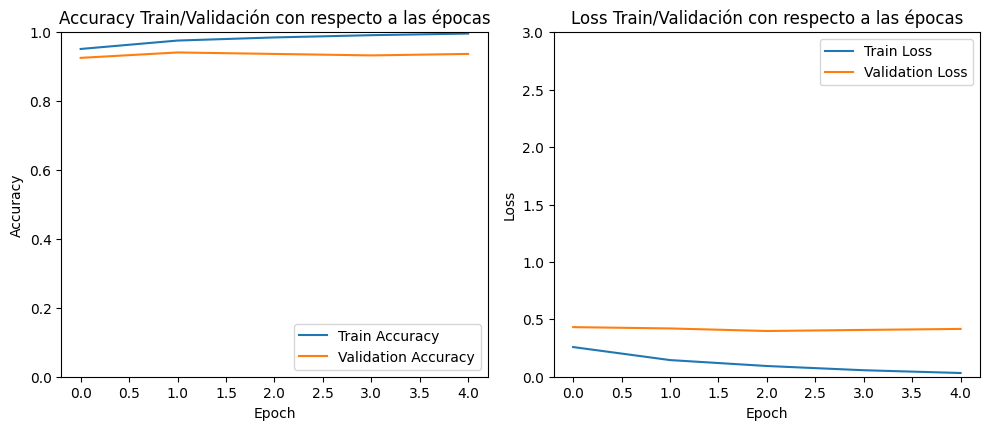

In [68]:
acc_loss_plot(ft_history)

### Modelo convolucional

In [33]:
import torch.nn as nn
import torch.nn.functional as F

# class SimpleCNN(nn.Module):
#     def __init__(self, num_classes):
#         super(SimpleCNN, self).__init__()

#         self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)  # (B, 32, 224, 224)
#         self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)       # (B, 32, 112, 112)

#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # (B, 64, 112, 112)
#         self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)       # (B, 64, 56, 56)

#         self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # (B, 128, 56, 56)
#         self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)        # (B, 128, 28, 28)

#         self.dropout = nn.Dropout(0.5)
#         self.fc1 = nn.Linear(128 * 28 * 28, 256)
#         self.fc2 = nn.Linear(256, num_classes)

#     def forward(self, x):
#         x = self.pool1(F.relu(self.conv1(x)))  # (B, 32, 112, 112)
#         x = self.pool2(F.relu(self.conv2(x)))  # (B, 64, 56, 56)
#         x = self.pool3(F.relu(self.conv3(x)))  # (B, 128, 28, 28)

#         x = x.view(x.size(0), -1)  # Flatten
#         x = self.dropout(x)
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)
#         return x

In [41]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()
        # Capas convolucionales con BatchNorm
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        # Capas fully connected
        self.fc1 = nn.Linear(256 * 14 * 14, 512)
        self.fc2 = nn.Linear(512, num_classes)

        # Regularización
        self.dropout = nn.Dropout(0.5)
        self.pool = nn.MaxPool2d(2, 2)

    def forward(self, x):
        # Bloque 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))  # 112x112
        # Bloque 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))  # 56x56
        # Bloque 3
        x = self.pool(F.relu(self.bn3(self.conv3(x))))  # 28x28
        # Bloque 4
        x = self.pool(F.relu(self.bn4(self.conv4(x))))  # 14x14

        x = x.view(x.size(0), -1)  # Flatten
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [64]:
# Create a neural net class
class Nett(nn.Module):


    # Defining the Constructor
    def __init__(self, num_classes=3):
        super(Nett, self).__init__()

        # In the init function, we define each layer we will use in our model

        # Our images are RGB, so we have input channels = 3.
        # We will apply 12 filters in the first convolutional layer
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=12, kernel_size=3, stride=1, padding=1)

        # A second convolutional layer takes 12 input channels, and generates 24 outputs
        self.conv2 = nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, stride=1, padding=1)

        # We in the end apply max pooling with a kernel size of 2
        self.pool = nn.MaxPool2d(kernel_size=2)

        # A drop layer deletes 20% of the features to help prevent overfitting
        self.drop = nn.Dropout2d(p=0.2)

        # Our 128x128 image tensors will be pooled twice with a kernel size of 2. 128/2/2 is 32.
        # This means that our feature tensors are now 32 x 32, and we've generated 24 of them

        # We need to flatten these in order to feed them to a fully-connected layer
        self.fc = nn.Linear(in_features=32 * 32 * 24, out_features=num_classes)

    def forward(self, x):
        # In the forward function, pass the data through the layers we defined in the init function

        # Use a ReLU activation function after layer 1 (convolution 1 and pool)
        x = F.relu(self.pool(self.conv1(x)))

        # Use a ReLU activation function after layer 2
        x = F.relu(self.pool(self.conv2(x)))

        # Select some features to drop to prevent overfitting (only drop during training)
        x = F.dropout(self.drop(x), training=self.training)

        # Flatten
        x = x.view(x.size(0), -1)
        # Feed to fully-connected layer to predict class
        x = self.fc(x)
        # Return class probabilities via a log_softmax function
        return torch.log_softmax(x, dim=1)

In [75]:
import torch.nn as nn
import torch.nn.functional as F

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=70):
        super(ImprovedCNN, self).__init__()

        # Capas convolucionales ampliadas
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1, stride=1),  # Mantenemos más información
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 112x112
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 56x56
        )

        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 28x28
        )

        self.layer4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, stride=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 14x14
        )

        # Capas fully connected rediseñadas
        self.fc1 = nn.Linear(256*14*14, 1024)  # Mayor capacidad
        self.fc2 = nn.Linear(1024, 512)
        self.fc3 = nn.Linear(512, num_classes)  # 70 clases de salida

        # Regularización
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = out.view(out.size(0), -1)  # Aplanar

        out = self.dropout(self.relu(self.fc1(out)))
        out = self.dropout(self.relu(self.fc2(out)))
        out = self.fc3(out)  # No aplicar ReLU en la última capa

        return out

In [83]:
cnn_model = ImprovedCNN(num_classes).to(device)

cnn_criterion = nn.CrossEntropyLoss()
cnn_optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=0.001,
                      weight_decay=0.01)
cnn_scheduler = optim.lr_scheduler.StepLR(cnn_optimizer, step_size=7, gamma=0.1)

In [84]:
cnn_model, cnn_history = train_model(cnn_model,
                         trainloader,
                         validloader,
                         cnn_criterion,
                         cnn_optimizer,
                         cnn_scheduler,
                         num_epochs=10,
                         device=device,
                         save_path='models/cnn_model.pth')

✅ Mejor modelo guardado
Epoch [1/10] - Loss: 4.2647 - Acc: 0.0149 - Val_Loss: 4.2505 - Val_Acc: 0.0186
✅ Mejor modelo guardado
Epoch [2/10] - Loss: 4.2661 - Acc: 0.0149 - Val_Loss: 4.2508 - Val_Acc: 0.0200
Epoch [3/10] - Loss: 4.2688 - Acc: 0.0164 - Val_Loss: 4.2506 - Val_Acc: 0.0200
Epoch [4/10] - Loss: 4.2667 - Acc: 0.0138 - Val_Loss: 4.2505 - Val_Acc: 0.0186
Epoch [5/10] - Loss: 4.2688 - Acc: 0.0140 - Val_Loss: 4.2506 - Val_Acc: 0.0200
Epoch [6/10] - Loss: 4.2696 - Acc: 0.0147 - Val_Loss: 4.2506 - Val_Acc: 0.0200
Epoch [7/10] - Loss: 4.2684 - Acc: 0.0142 - Val_Loss: 4.2505 - Val_Acc: 0.0200
Epoch [8/10] - Loss: 4.2650 - Acc: 0.0152 - Val_Loss: 4.2504 - Val_Acc: 0.0186
Epoch [9/10] - Loss: 4.2690 - Acc: 0.0157 - Val_Loss: 4.2506 - Val_Acc: 0.0186
Epoch [10/10] - Loss: 4.2702 - Acc: 0.0137 - Val_Loss: 4.2504 - Val_Acc: 0.0186
Entrenamiento finalizado


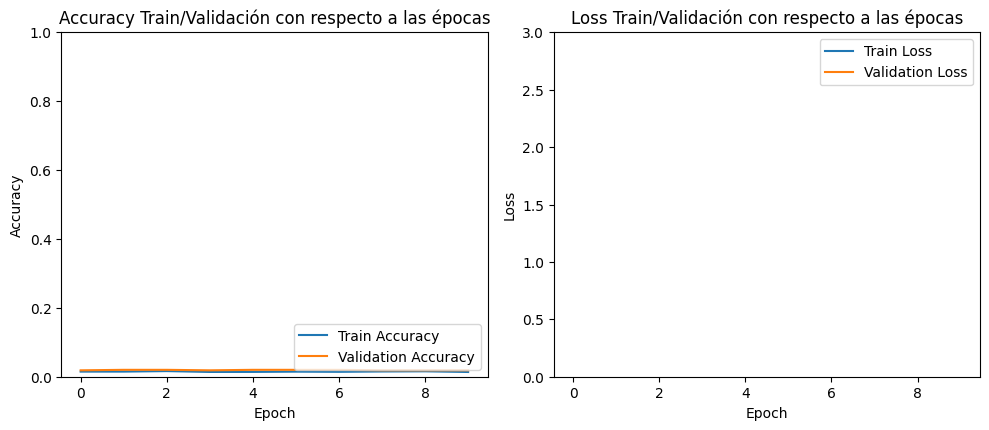

In [85]:
acc_loss_plot(cnn_history)

## Métricas y Predicciones obtenidas

In [69]:
# ==== Carga de Modelo existente ====
# base_model = models.resnet18(pretrained=False)
# base_model.fc = nn.Linear(base_model.fc.in_features, len(class_names))
# base_model.load_state_dict(torch.load("models/base_model.pth", map_location=device))
# base_model = base_model.to(device)
# base_model.eval()

_, true_labels_base, pred_labels_base = get_predictions(model=base_model, dataloader=testloader, device=device)

metrics_base = compute_metrics(
    y_true=true_labels_base,
    y_pred=pred_labels_base,
    labels=list(range(len(class_names))),
    average='macro'
)

In [71]:
#==== Carga de Modelo Fine-Tuned Existente ====
# ft_model = models.resnet18(pretrained=False)
# ft_model.fc = nn.Linear(ft_model.fc.in_features, len(class_names))
# ft_model.load_state_dict(torch.load("models/ft_rn18_model.pth", map_location=device))
# ft_model = ft_model.to(device)
# ft_model.eval()

_, true_labels_ft, pred_labels_ft = get_predictions(model=ft_model, dataloader=testloader, device=device)

metrics_ft = compute_metrics(
    y_true=true_labels_ft,
    y_pred=pred_labels_ft,
    labels=list(range(len(class_names))),
    average='macro'
)

In [ ]:
#==== Carga de Modelo Convolucional Existente ====


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step


### Matrices de confusión

In [72]:
#plot_confusion_matrix(y_true_cnn, y_pred_cnn, classes=class_names, title="Matriz de Confusión - CNN")
plot_confusion_matrix(true_labels_base, pred_labels_base, classes = testloader.dataset.classes, title='Base ResNet18 - Matriz de Confusión')
plot_confusion_matrix(true_labels_ft, pred_labels_ft, classes=testset.classes, title='Fine-tuned ResNet18 - Matriz de Confusión')

Se obseva que ambos modelos de ResNet logran captar correctamente las carácterísticas de cada imagen y lograr una buena clasificación. En cambio, el modelo convolucional presenta algunas dificultades a la hora de reconocer ciertas clases

#### Métricas

In [ ]:
metrics_df = pd.DataFrame([
    metrics_base,
    metrics_ft,
    metrics_cnn
], index=['ResNet18 Base', 'ResNet18 Fine-Tuned', 'CNN'])

metrics_df.to_csv("outputs/metricas_modelos.csv")

In [ ]:
metrics_df.round(2)

,Exactitud (Accuracy),Precisión (Precision),Sensibilidad (Recall),F1 Score,Especificidad (avg)
ResNet18 Base,0.94,0.95,0.94,0.94,1.00
ResNet18 Fine-Tuned,0.97,0.97,0.97,0.97,1.00
CNN,0.49,0.57,0.49,0.49,0.99


Como era de esperarse, el modelo de ResNet18 con un fine-tunning realizado es el que logra el mejor rendimiento en general. El modelo de ResNet ofrese un desempeño sólido aunque levemente inferior, siendo este una buena alternativa cuando se busca reducir el tiempo de entrenamiento. Por otro lado, la CNN muestra un rendimiento pobre

## Interfaz de Gradio

Para la interfaz se dará la opción de elegir el modelo de CNN y ResNet18 fine-tunned dado que el logró mejores métricas que su verrsión base

In [91]:
rn_index, rn_image_paths, rn_image_labels = prepare_faiss_index(testloader, ft_model, device, class_names)

Procesando ResNet50: 100%|██████████| 22/22 [00:03<00:00,  5.89it/s]


In [94]:
# def find_similar_images_torch(img_tensor, model, index, image_paths, image_labels, device, k=10):
#     # Preprocesamiento: resize + normalize como en entrenamiento
#     transform = transforms.Compose([
#         transforms.Resize((224, 224)),
#         transforms.ToTensor(),
#         # transforms.Normalize((0.5,), (0.5,))
#         transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
#     ])

#     if isinstance(img_tensor, np.ndarray):
#         img = Image.fromarray(img_tensor.astype("uint8"))
#     else:
#         img = img_tensor  # ya es PIL.Image

#     img = transform(img).unsqueeze(0).to(device)  # [1, 3, 224, 224]

#     model.eval()
#     with torch.no_grad():
#         features = model(img).cpu().numpy().astype("float32")  # [1, feature_dim]

#     distances, indices = index.search(features, k)

#     similar_images = [(image_paths[i], image_labels[i], float(distances[0][j]))
#                       for j, i in enumerate(indices[0])]

#     breeds = [label for _, label, _ in similar_images]
#     predicted_breed = Counter(breeds).most_common(1)[0][0]

#     return similar_images, predicted_breed

In [95]:
def gradio_interface(img, model_selector):
    if model_selector == "CNN (Keras)":
        similar_images, predicted_breed = find_similar_images(img, cnn_model, cnn_index, cnn_image_paths, cnn_image_labels)
    elif model_selector == "ResNet18 Fine-Tuned (PyTorch)":
        similar_images, predicted_breed = find_similar_images_torch(
            img,
            model=ft_model,
            index=rn_index,
            image_paths=rn_image_paths,
            image_labels=rn_image_labels,
            device=device
        )
    else:
        return [], "Modelo no reconocido", ""

    output_imgs = [plt.imread(path) for path, _, _ in similar_images]
    return output_imgs, predicted_breed, f"{model_selector} - búsqueda completada"

# --- Crear la interfaz ---
iface = gr.Interface(
    fn=gradio_interface,
    inputs=[
        gr.Image(type="numpy", label="Sube una imagen de perro"),
        gr.Dropdown(choices=["CNN (Keras)", "ResNet18 Fine-Tuned (PyTorch)"], label="Selecciona el modelo")
    ],
    outputs=[
        gr.Gallery(label="Imágenes más similares", columns=5),
        gr.Textbox(label="Predicción de raza por mayoría"),
        gr.Textbox(label="Estado")
    ],
    title="Buscador de Similitud por Modelo",
    description="Sube una imagen de perro y elige qué modelo usar para encontrar imágenes similares."
)

iface.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://deff9ad7b019a76952.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# **Etapa 3**: Pipeline de Detección y Clasificación en Escenas Complejas

Se usará YOLOv8 para la detección de objetos.

En una primera instancia, comienzo utilizando la versíon más básica del mismo y en caso de no lograr un buen desempeño iré usando versiones más complejas. Esto es para no utilizar recursos adicionales sin motivos suficientes

Una vez detectado el/los objeto/s, se pasará un recorte del mismo para ser clasificado por ResNet18 fine-tunned, dado que fue el modelo con mejores resultados

## Comparasión Nano - Small

In [97]:
yolon_model = YOLO("yolov8n-seg.pt")
yolosn_model = YOLO("yolov8s-seg.pt")

yolon_model.info()
yolosn_model.info()

100%|██████████| 6.74M/6.74M [00:00<00:00, 132MB/s]


100%|██████████| 22.8M/22.8M [00:00<00:00, 93.6MB/s]


YOLOv8n-seg summary: 151 layers, 3,409,968 parameters, 0 gradients, 12.8 GFLOPs
YOLOv8s-seg summary: 151 layers, 11,821,056 parameters, 0 gradients, 42.9 GFLOPs


(151, 11821056, 0, 42.860595200000006)

0: 640x640 4 dogs, 731.0ms
1: 640x640 6 dogs, 731.0ms
Speed: 12.9ms preprocess, 731.0ms inference, 108.3ms postprocess per image at shape (1, 3, 640, 640)

0: 640x640 2 dogs, 1271.0ms
1: 640x640 6 dogs, 1271.0ms
Speed: 3.3ms preprocess, 1271.0ms inference, 31.2ms postprocess per image at shape (1, 3, 640, 640)
Results saved to outputs/yolo_small_results
2 labels saved to outputs/yolo_small_results/labels


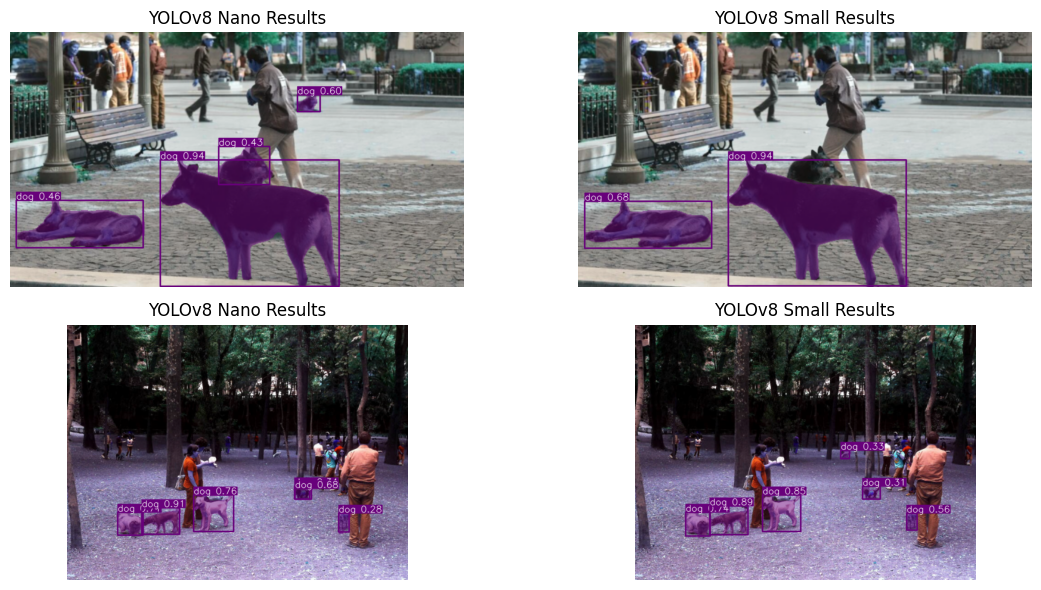

In [ ]:
# # Perform inference on a sample image
# image_path = ["/workspace/ciudad.jpg", '/workspace/parque.jpg']

# nano_results = yolon_model(image_path, save = False, project = 'outputs', name = 'yolo_nano_results', classes = [16])
# small_results = yolosn_model(image_path, save= False, project = 'outputs', name = 'yolo_small_results' ,classes = [16])


# # Crear una figura con dos subplots lado a lado
# fig, axs = plt.subplots(2, 2, figsize=(12, 6))

# for i in range(2):
#     axs[i][0].imshow(nano_results[i].plot())
#     axs[i][0].set_title("YOLOv8 Nano Results")
#     axs[i][0].axis('off')

#     axs[i][1].imshow(small_results[i].plot())
#     axs[i][1].set_title("YOLOv8 Small Results")
#     axs[i][1].axis('off')

# plt.tight_layout()
# plt.show()

## Definición de funciones necesarias

In [98]:
def get_crops_from_result(result, image):
    """
    Dado un resultado de YOLOv8 y la imagen original,
    devuelve una lista de recortes (PIL.Image) de cada detección.
    """
    boxes = result.boxes.xyxy.cpu().numpy().astype(int)  # coordenadas [x1, y1, x2, y2]
    crops = []
    for x1, y1, x2, y2 in boxes:
        crop = image.crop((x1, y1, x2, y2))  # recorte con PIL
        crops.append(crop)
    return crops

In [117]:
def yolo_inference(image, model):
    """
    Realiza inferencia con un modelo YOLOv8 sobre una imagen PIL.
    Devuelve coordenadas de las cajas y recortes (PIL).
    """
    results = model(image, classes = [16])

    # Obtener coordenadas de las cajas [x1, y1, x2, y2]
    boxes = results[0].boxes.xyxy.cpu().numpy().astype(int).tolist()
    crops = get_crops_from_result(results[0], image)

    return boxes, crops

In [100]:
def get_resnet18_prediction(crop, model, device, class_names):
    """
    Realiza una predicción de raza de perro usando un modelo ResNet18.

    Args:
        crop (PIL.Image): Recorte de la imagen del perro.
        model (nn.Module): Modelo ResNet18 cargado.
        device (torch.device): Dispositivo donde se ejecuta el modelo.
        class_names (list): Lista de nombres de clases.

    Returns:
        str: Nombre de la raza predicha.
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(crop).unsqueeze(0).to(device)  # [1, 3, 224, 224]

    model.eval()
    with torch.no_grad():
        output = model(img_tensor)

    _, predicted_idx = torch.max(output, 1)
    return class_names[predicted_idx.item()]

In [1]:
def detection_pipeline(image, model):
    """
    La función se encargará de realizar la todo el proceso de
    detección de perros con YOLOv8 y la clasificación de sus razas con ResNet18.

    Args:
        image (PIL.Image): Imagen PIL de la escena.
        model (YOLO): Modelo YOLOv8 para la detección de perros.

    Returns:
        image_with_boxes(PIL.Image): Imagen con los bounding boxes de cada perro detectado
        labeled_gallery_items (list): Lista de tuplas (recorte, raza predicha) para cada perro detectado.

    """

    # Paso 1: Detección con YOLO
    bboxes, crops = yolo_inference(image, model)

    # Dibujar los bounding boxes sobre una copia de la imagen original
    image_with_boxes = image.copy()
    draw = ImageDraw.Draw(image_with_boxes)
    for box in bboxes:
        draw.rectangle(box, outline="red", width=3)

    # Paso 2: Clasificación con ResNet18
    labeled_gallery_items = []
    for crop in crops:
        breed = get_resnet18_prediction(crop, ft_model, device, class_names)
        labeled_gallery_items.append((crop, breed))

    return image_with_boxes, labeled_gallery_items

### Interfaz de Gradio

In [123]:


# Gradio interface
iface = gr.Interface(
    fn=partial(detection_pipeline, model=yolosn_model),
    inputs=gr.Image(type="pil", label="Subí una imagen con perros"),
    outputs=[
        gr.Image(label="Imagen con detecciones"),
        gr.Gallery(label="Recortes", columns=5, object_fit="contain")
    ],
    title="Detector y Clasificador de Razas de Perros 🐶",
    description="Subí una imagen con uno o varios perros. La app detectará los perros con YOLOv8 y clasificará su raza con ResNet18."
)
iface.launch()


It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://706669eba7891e05a8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
